# Phase III Mesh Size Comparison: Re = 10

This notebook solves the square lid-driven cavity problem at a fixed Reynolds number, `Re = 10`, for four odd-node meshes:

| Mesh | Nodes |
|---|---:|
| Coarse | `9 x 9` |
| Medium | `17 x 17` |
| Fine | `33 x 33` |
| Finest | `65 x 65` |

The solver is patched in memory, so `main_solver.py` is not modified. Results are cached after each mesh so rerunning the plotting cells does not require solving every case again. The plotting section keeps the meshes on shared figures using subplots.

In [1]:
from pathlib import Path
import contextlib
import io
import json
import os
import shutil
import time

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if Path.cwd().name != "start-code" and (Path.cwd() / "start-code").exists():
    os.chdir(Path.cwd() / "start-code")

plot_dir = Path("Phase III Mesh Comparison Re10")
plot_dir.mkdir(exist_ok=True)

cache_dir = plot_dir / "case_cache"
cache_dir.mkdir(exist_ok=True)

print(f"Working directory: {Path.cwd()}")
print(f"Plot output directory: {plot_dir.resolve()}")
print(f"Cache directory: {cache_dir.resolve()}")

Working directory: /Users/windy/mae4100-courseproject2/start-code
Plot output directory: /Users/windy/mae4100-courseproject2/start-code/Phase III Mesh Comparison Re10
Cache directory: /Users/windy/mae4100-courseproject2/start-code/Phase III Mesh Comparison Re10/case_cache


In [2]:
REYNOLDS_NUMBER = 10.0
CFL = 0.5
KAPPA = 0.5
C4 = 0.01
TOLERANCE = 1e-8
MAX_ITERATIONS = None

# Square cavity dimensions from the base project setup.
CAVITY_WIDTH = 0.05
CAVITY_HEIGHT = 0.05

MESH_CASES = [
    {"name": "9 x 9", "label": "mesh_9x9", "nodes": 9},
    {"name": "17 x 17", "label": "mesh_17x17", "nodes": 17},
    {"name": "33 x 33", "label": "mesh_33x33", "nodes": 33},
    {"name": "65 x 65", "label": "mesh_65x65", "nodes": 65},
]

USE_CACHE = True
FORCE_RERUN = False

pd.DataFrame([
    {
        "mesh": case["name"],
        "Re": REYNOLDS_NUMBER,
        "width (m)": CAVITY_WIDTH,
        "height (m)": CAVITY_HEIGHT,
        "dx = dy (m)": CAVITY_WIDTH / (case["nodes"] - 1),
        "CFL": CFL,
        "kappa": KAPPA,
        "C4": C4,
        "tolerance": TOLERANCE,
    }
    for case in MESH_CASES
])

,mesh,Re,width (m),height (m),dx = dy (m),CFL,kappa,C4,tolerance
0,9 x 9,10.0,0.05,0.05,0.006250,0.5,0.5,0.01,1.000000e-08
1,17 x 17,10.0,0.05,0.05,0.003125,0.5,0.5,0.01,1.000000e-08
2,33 x 33,10.0,0.05,0.05,0.001563,0.5,0.5,0.01,1.000000e-08
3,65 x 65,10.0,0.05,0.05,0.000781,0.5,0.5,0.01,1.000000e-08


In [3]:
MAIN_PLOT_FILES = [
    "ucontour.png",
    "vcontour.png",
    "pcontour.png",
    "residualcomponent.png",
    "residual.png",
]


def format_solver_float(value):
    return f"{value:<16g}"


def apply_replacements(source, replacements, solver_path):
    for old, new in replacements.items():
        if old not in source:
            raise RuntimeError(f"Could not find expected setting in {solver_path}: {old}")
        source = source.replace(old, new, 1)
    return source


def patched_solver_source(case):
    node_count = case["nodes"]
    solver_path = Path("main_solver.py")
    source = solver_path.read_text()

    replacements = {
        "imax = 9               # Number of points in the x-direction (use odd numbers only)":
            f"imax = {node_count:<15}# Number of points in the x-direction (use odd numbers only)",
        "jmax = 9               # Number of points in the y-direction (use odd numbers only)":
            f"jmax = {node_count:<15}# Number of points in the y-direction (use odd numbers only)",
        "xmax = 0.05            # Maximum x location (m)":
            f"xmax = {format_solver_float(CAVITY_WIDTH)}# Maximum x location (m)",
        "ymax = 0.05            # Maximum y location (m)":
            f"ymax = {format_solver_float(CAVITY_HEIGHT)}# Maximum y location (m)",
        "iterout = 5000         # Number of time steps between solution output":
            "iterout = 100000000    # Number of time steps between solution output",
        "cfl = 0.5              # CFL number used to determine time step":
            f"cfl = {format_solver_float(CFL)}# CFL number used to determine time step",
        "Cx = 0.01              # Parameter for 4th order artificial viscosity in x":
            f"Cx = {format_solver_float(C4)}# Parameter for 4th order artificial viscosity in x",
        "Cy = 0.01              # Parameter for 4th order artificial viscosity in y":
            f"Cy = {format_solver_float(C4)}# Parameter for 4th order artificial viscosity in y",
        "toler = 1e-10          # Tolerance for iterative residual convergence":
            f"toler = {format_solver_float(TOLERANCE)}# Tolerance for iterative residual convergence",
        "rkappa = 0.5           # Time derivative preconditioning constant":
            f"rkappa = {format_solver_float(KAPPA)}# Time derivative preconditioning constant",
        "Re = 10.0              # Reynolds number = rho*Uinf*L/rmu":
            f"Re = {format_solver_float(REYNOLDS_NUMBER)}# Reynolds number = rho*Uinf*L/rmu",
        "vectorize = False":
            "vectorize = True",
        "u = SGS_forward_sweep(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)":
            "u = SGS_forward_sweep_acc(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)",
        "u = SGS_backward_sweep(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)":
            "u = SGS_backward_sweep_acc(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)",
    }

    if MAX_ITERATIONS is not None:
        replacements["nmax = 500000          # Maximum number of iterations"] = (
            f"nmax = {MAX_ITERATIONS:<15}# Maximum number of iterations"
        )

    return solver_path, apply_replacements(source, replacements, solver_path)


def archive_solver_plots(label):
    case_plot_dir = plot_dir / label
    case_plot_dir.mkdir(exist_ok=True)
    for filename in MAIN_PLOT_FILES:
        src = Path(filename)
        if src.exists():
            dst = case_plot_dir / filename
            if dst.exists():
                dst.unlink()
            shutil.move(str(src), str(dst))


def cache_paths(case):
    label = case["label"]
    return cache_dir / f"{label}.npz", cache_dir / f"{label}.json"


def save_case_cache(case, result):
    npz_path, json_path = cache_paths(case)
    np.savez_compressed(
        npz_path,
        u=result["u"],
        x=result["x"],
        y=result["y"],
        conv_history=result["conv_history"],
        residual_history=result["residual_history"],
        final_residual=result["final_residual"],
    )
    metadata = {
        key: value
        for key, value in result.items()
        if key not in {"u", "x", "y", "conv_history", "residual_history", "final_residual", "captured_output"}
    }
    metadata["captured_output_tail"] = result["captured_output"].splitlines()[-12:]
    json_path.write_text(json.dumps(metadata, indent=2))


def load_case_cache(case):
    npz_path, json_path = cache_paths(case)
    if not npz_path.exists() or not json_path.exists():
        return None

    arrays = np.load(npz_path)
    metadata = json.loads(json_path.read_text())
    metadata.update({
        "u": arrays["u"],
        "x": arrays["x"],
        "y": arrays["y"],
        "conv_history": arrays["conv_history"],
        "residual_history": arrays["residual_history"],
        "final_residual": arrays["final_residual"],
        "captured_output": "\n".join(metadata.pop("captured_output_tail", [])),
    })
    return metadata


def run_mesh_case(case):
    cached = load_case_cache(case) if USE_CACHE and not FORCE_RERUN else None
    if cached is not None:
        print(f"Loaded cached result for {case['name']}")
        return cached

    solver_path, source = patched_solver_source(case)
    namespace = {
        "__file__": str(solver_path.resolve()),
        "__name__": "__main__",
    }

    print(f"Running mesh {case['name']}: Re={REYNOLDS_NUMBER:g}")
    start_time = time.perf_counter()
    with contextlib.redirect_stdout(io.StringIO()) as captured_output:
        exec(compile(source, str(solver_path), "exec"), namespace)
    elapsed_time = time.perf_counter() - start_time

    archive_solver_plots(case["label"])
    plt.close("all")

    u = namespace["u"].copy()
    imax, jmax, _ = u.shape
    x_coords = np.linspace(namespace["xmin"], namespace["xmax"], imax)
    y_coords = np.linspace(namespace["ymin"], namespace["ymax"], jmax)

    result = {
        "name": case["name"],
        "label": case["label"],
        "nodes": int(case["nodes"]),
        "Re": REYNOLDS_NUMBER,
        "CFL": CFL,
        "kappa": KAPPA,
        "C4": C4,
        "tolerance": TOLERANCE,
        "width": float(namespace["xmax"] - namespace["xmin"]),
        "height": float(namespace["ymax"] - namespace["ymin"]),
        "dx": float(namespace["dx"]),
        "dy": float(namespace["dy"]),
        "viscosity": float(namespace["rmu"]),
        "iterations": int(namespace["n"]),
        "converged": bool(namespace["isConverged"]),
        "final_conv": float(namespace["conv"]),
        "elapsed_time_sec": float(elapsed_time),
        "x": x_coords,
        "y": y_coords,
        "u": u,
        "final_residual": np.array(namespace["res"], copy=True),
        "conv_history": np.array(namespace["convVector"], copy=True),
        "residual_history": np.array(namespace["resPMatrix"], copy=True),
        "captured_output": captured_output.getvalue(),
    }
    save_case_cache(case, result)
    return result


def build_summary(results):
    return pd.DataFrame([
        {
            "mesh": result["name"],
            "nodes": f"{result['nodes']}x{result['nodes']}",
            "Re": result["Re"],
            "dx (m)": result["dx"],
            "dy (m)": result["dy"],
            "viscosity (N*s/m^2)": result["viscosity"],
            "iterations": result["iterations"],
            "converged": result["converged"],
            "final conv": result["final_conv"],
            "wall time (s)": result["elapsed_time_sec"],
        }
        for result in results
    ])

In [4]:
results = []
for case in MESH_CASES:
    result = run_mesh_case(case)
    results.append(result)
    print(
        f"Finished {result['name']}: "
        f"iterations={result['iterations']}, "
        f"converged={result['converged']}, "
        f"final_conv={result['final_conv']:.3e}, "
        f"wall_time={result['elapsed_time_sec']:.2f} s"
    )

summary = build_summary(results)
summary.to_csv(plot_dir / "mesh_comparison_summary.csv", index=False)
summary

Running mesh 9 x 9: Re=10
Finished 9 x 9: iterations=504, converged=True, final_conv=9.772e-09, wall_time=2.62 s
Running mesh 17 x 17: Re=10
Finished 17 x 17: iterations=1573, converged=True, final_conv=9.787e-09, wall_time=7.79 s
Running mesh 33 x 33: Re=10
Finished 33 x 33: iterations=6834, converged=True, final_conv=9.975e-09, wall_time=72.57 s
Running mesh 65 x 65: Re=10
Finished 65 x 65: iterations=29565, converged=True, final_conv=9.992e-09, wall_time=618.74 s


,mesh,nodes,Re,dx (m),dy (m),viscosity (N*s/m^2),iterations,converged,final conv,wall time (s)
0,9 x 9,9x9,10.0,0.006250,0.006250,0.005,504,True,9.772196e-09,2.623145
1,17 x 17,17x17,10.0,0.003125,0.003125,0.005,1573,True,9.787253e-09,7.792319
2,33 x 33,33x33,10.0,0.001563,0.001563,0.005,6834,True,9.975058e-09,72.566409
3,65 x 65,65x65,10.0,0.000781,0.000781,0.005,29565,True,9.992345e-09,618.738440


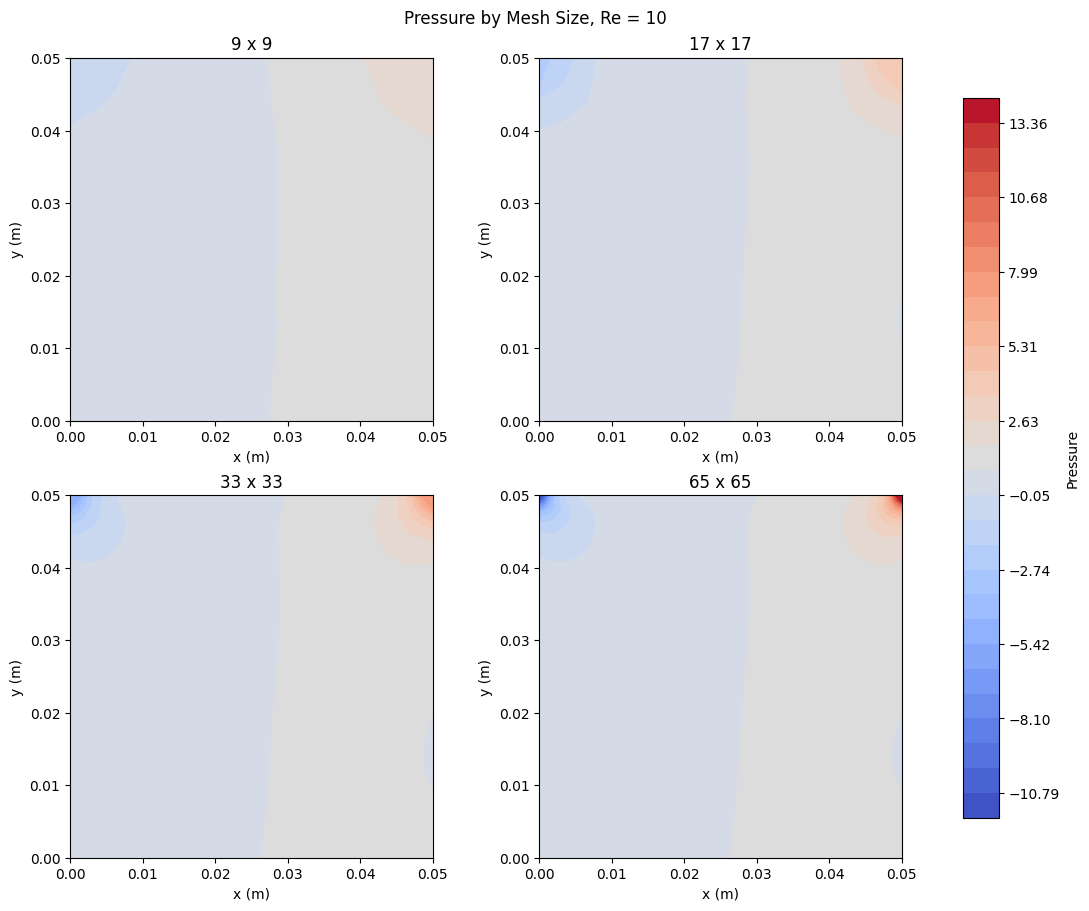

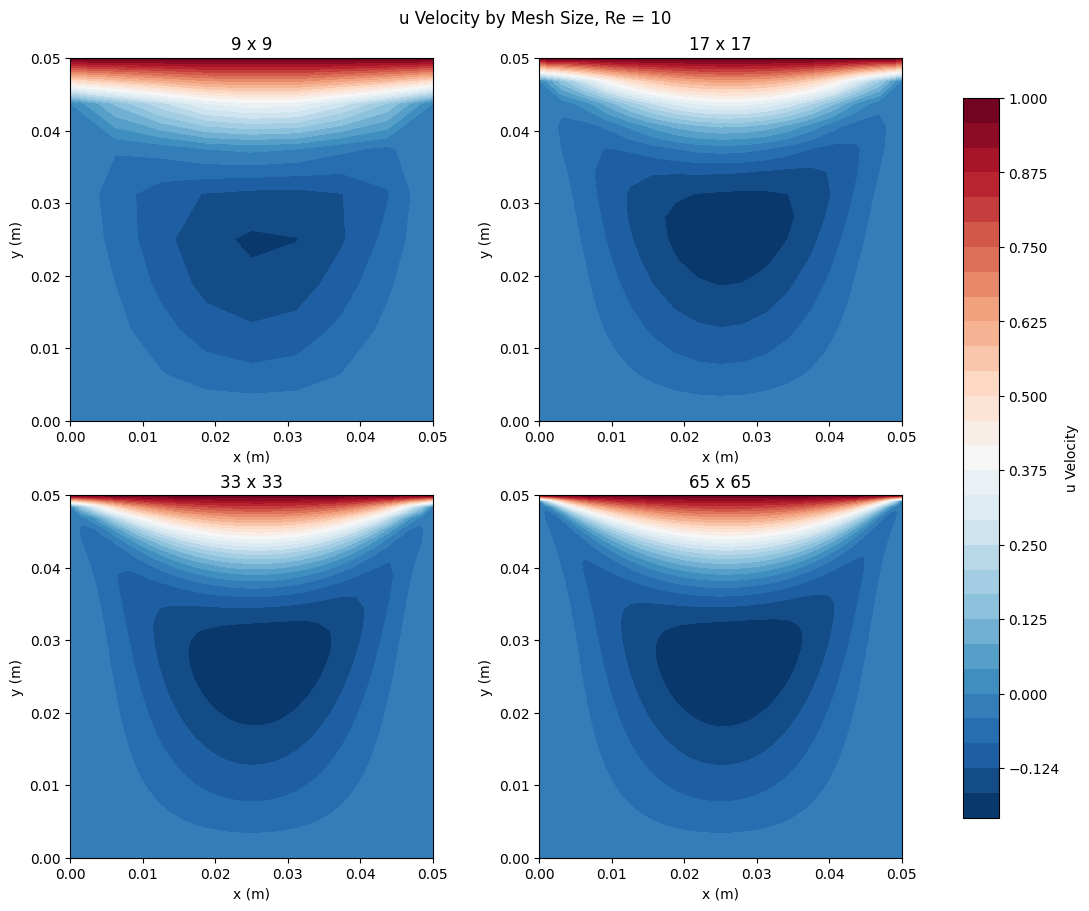

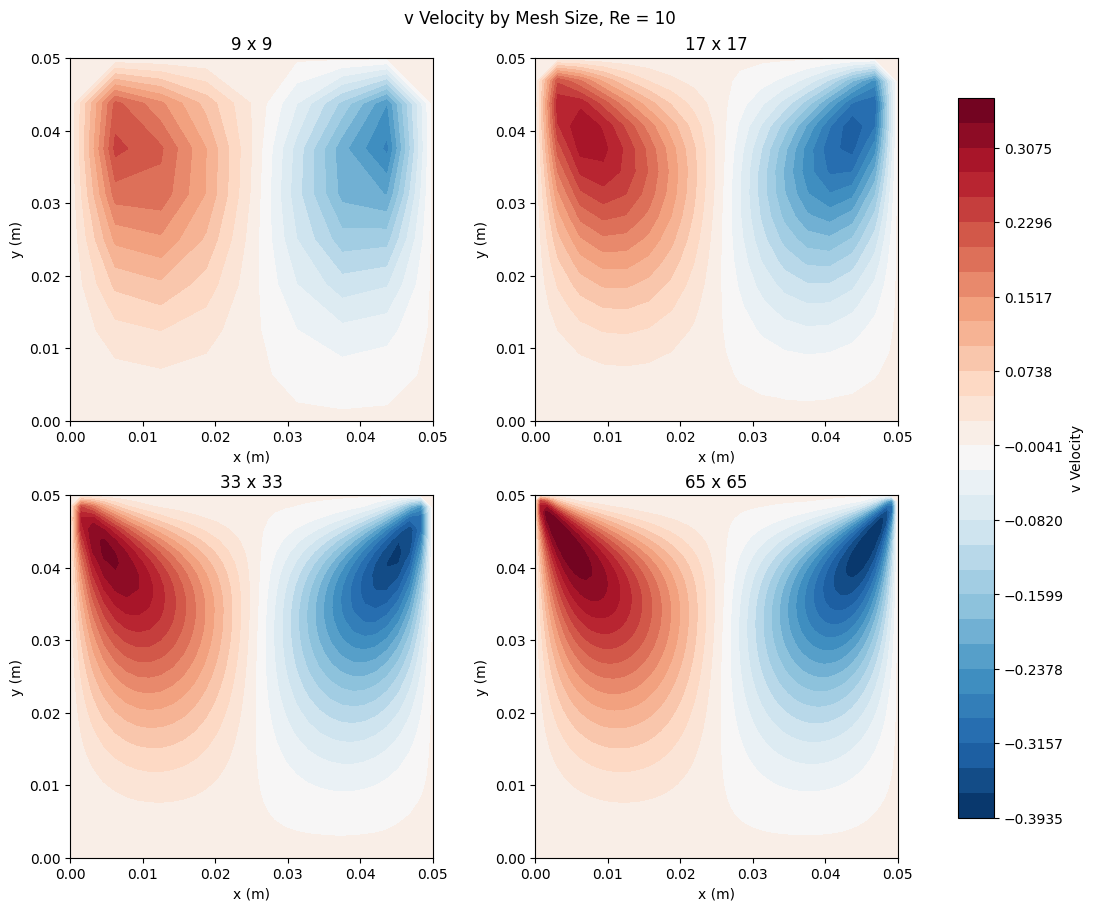

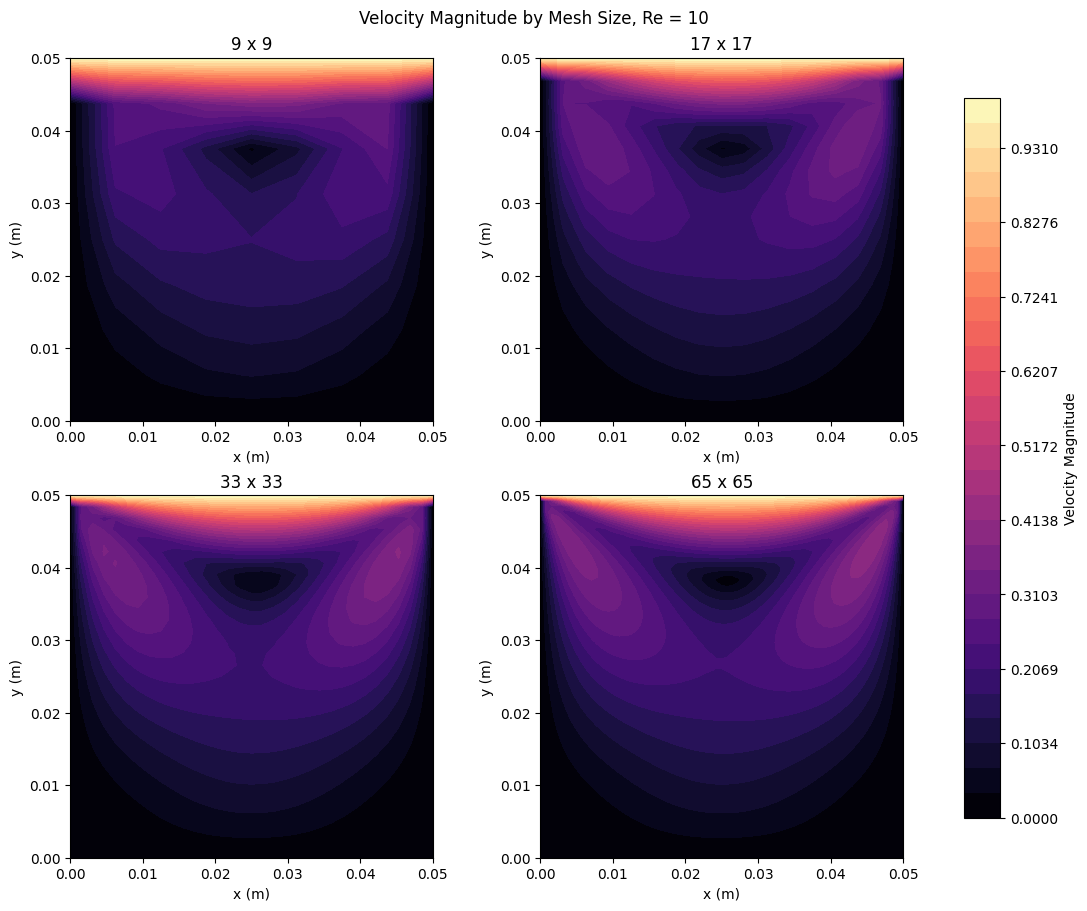

Saved subplot figures:
Phase III Mesh Comparison Re10/pressure_mesh_subplots.png
Phase III Mesh Comparison Re10/u_velocity_mesh_subplots.png
Phase III Mesh Comparison Re10/v_velocity_mesh_subplots.png
Phase III Mesh Comparison Re10/velocity_magnitude_mesh_subplots.png


In [5]:
def velocity_magnitude(result):
    return np.sqrt(result["u"][:, :, 1] ** 2 + result["u"][:, :, 2] ** 2)


def shared_limits(results, field_getter):
    values = [field_getter(result) for result in results]
    return min(float(np.min(value)) for value in values), max(float(np.max(value)) for value in values)


def plot_contour_subplots(results, field_name, field_getter, cmap="viridis", levels=30):
    vmin, vmax = shared_limits(results, field_getter)
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
    axes = axes.ravel()
    contour = None

    for ax, result in zip(axes, results):
        x_grid, y_grid = np.meshgrid(result["x"], result["y"], indexing="ij")
        contour = ax.contourf(
            x_grid,
            y_grid,
            field_getter(result),
            levels=np.linspace(vmin, vmax, levels),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(result["name"])
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.set_aspect("equal")

    fig.colorbar(contour, ax=axes, shrink=0.9, label=field_name)
    fig.suptitle(f"{field_name} by Mesh Size, Re = {REYNOLDS_NUMBER:g}")
    output_path = plot_dir / f"{field_name.lower().replace(' ', '_')}_mesh_subplots.png"
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    return output_path


p_path = plot_contour_subplots(results, "Pressure", lambda result: result["u"][:, :, 0], cmap="coolwarm")
u_path = plot_contour_subplots(results, "u Velocity", lambda result: result["u"][:, :, 1], cmap="RdBu_r")
v_path = plot_contour_subplots(results, "v Velocity", lambda result: result["u"][:, :, 2], cmap="RdBu_r")
speed_path = plot_contour_subplots(results, "Velocity Magnitude", velocity_magnitude, cmap="magma")

print("Saved subplot figures:")
for path in [p_path, u_path, v_path, speed_path]:
    print(path)

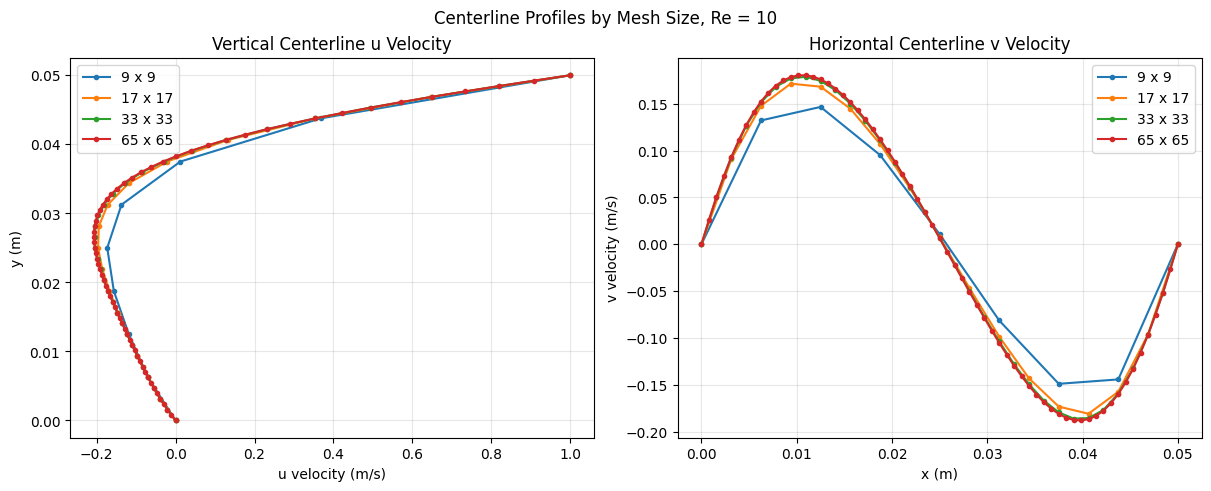

Phase III Mesh Comparison Re10/centerline_profiles_mesh_comparison.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

for result in results:
    u = result["u"]
    i_mid = (result["nodes"] - 1) // 2
    j_mid = (result["nodes"] - 1) // 2

    axes[0].plot(u[i_mid, :, 1], result["y"], marker="o", markersize=3, label=result["name"])
    axes[1].plot(result["x"], u[:, j_mid, 2], marker="o", markersize=3, label=result["name"])

axes[0].set_title("Vertical Centerline u Velocity")
axes[0].set_xlabel("u velocity (m/s)")
axes[0].set_ylabel("y (m)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Horizontal Centerline v Velocity")
axes[1].set_xlabel("x (m)")
axes[1].set_ylabel("v velocity (m/s)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle(f"Centerline Profiles by Mesh Size, Re = {REYNOLDS_NUMBER:g}")
centerline_path = plot_dir / "centerline_profiles_mesh_comparison.png"
fig.savefig(centerline_path, dpi=300, bbox_inches="tight")
plt.show()
print(centerline_path)

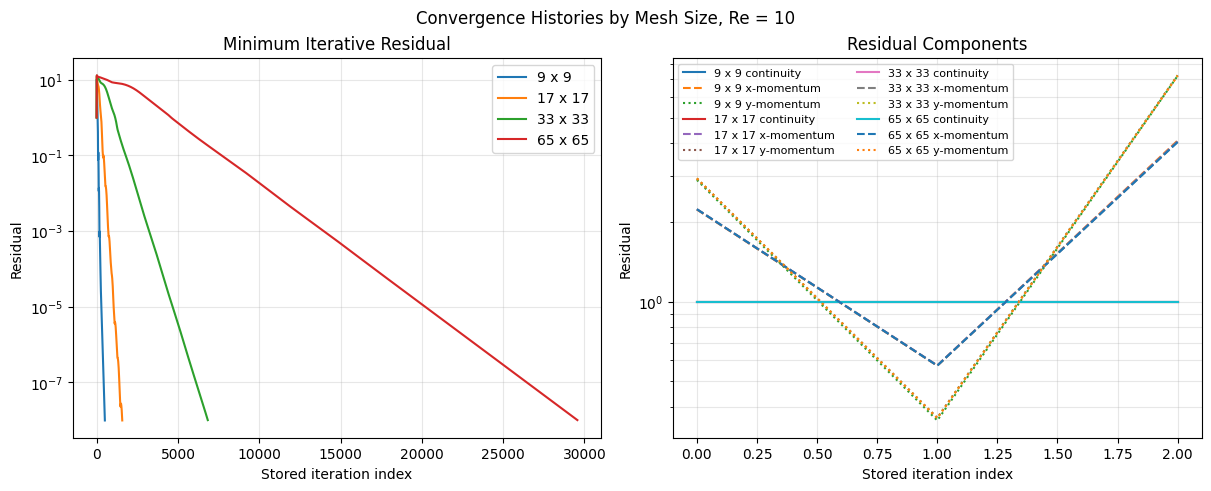

Phase III Mesh Comparison Re10/residual_histories_mesh_comparison.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

for result in results:
    conv_history = np.asarray(result["conv_history"])
    residual_history = np.asarray(result["residual_history"])

    if conv_history.size:
        axes[0].semilogy(conv_history, label=result["name"])

    if residual_history.size:
        axes[1].semilogy(residual_history[:, 0], label=f"{result['name']} continuity")
        axes[1].semilogy(residual_history[:, 1], linestyle="--", label=f"{result['name']} x-momentum")
        axes[1].semilogy(residual_history[:, 2], linestyle=":", label=f"{result['name']} y-momentum")

axes[0].set_title("Minimum Iterative Residual")
axes[0].set_xlabel("Stored iteration index")
axes[0].set_ylabel("Residual")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

axes[1].set_title("Residual Components")
axes[1].set_xlabel("Stored iteration index")
axes[1].set_ylabel("Residual")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=8, ncol=2)

fig.suptitle(f"Convergence Histories by Mesh Size, Re = {REYNOLDS_NUMBER:g}")
residual_path = plot_dir / "residual_histories_mesh_comparison.png"
fig.savefig(residual_path, dpi=300, bbox_inches="tight")
plt.show()
print(residual_path)